# Task 1 - Data Merge and EDA

Merging `customer_social_profiles` and `customer_transactions` into one dataset, then
exploring it before building the product recommendation model.

Samuel Kwizera Ihimbazwe

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency

pd.set_option('display.width', 150)
sns.set_style('whitegrid')

## 1. The two raw tables

The join is not obvious, so it is worth looking at both keys before merging anything.

In [2]:
social = pd.read_csv('../data/raw/customer_social_profiles.csv')
trans = pd.read_csv('../data/raw/customer_transactions.csv')

print('social', social.shape)
display(social.head())
print('transactions', trans.shape)
display(trans.head())

social (155, 5)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


transactions (150, 6)


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


In [3]:
print('social dtypes'); print(social.dtypes)
print()
print('transaction dtypes'); print(trans.dtypes)
print()
print('social duplicate rows:', social.duplicated().sum())
print('transaction duplicate rows:', trans.duplicated().sum())
print()
print('nulls'); print(trans.isna().sum()[trans.isna().sum() > 0])

social dtypes
customer_id_new                str
social_media_platform          str
engagement_score             int64
purchase_interest_score    float64
review_sentiment               str
dtype: object

transaction dtypes
customer_id_legacy      int64
transaction_id          int64
purchase_amount         int64
purchase_date             str
product_category          str
customer_rating       float64
dtype: object

social duplicate rows: 5
transaction duplicate rows: 0

nulls
customer_rating    10
dtype: int64


### The join key problem

The two tables do not share a key. Social profiles use `customer_id_new` (`A178`, a string)
and transactions use `customer_id_legacy` (`178`, an integer). Stripping the `A` puts both
onto the same `100-199` range, and there is no mapping table or any other candidate key in
either file, so that is the only join available.

It is worth being honest about how strong that assumption is.

In [4]:
sid = social['customer_id_new'].str.extract(r'(\d+)')[0].astype(int)
tid = trans['customer_id_legacy']

a, b = set(sid), set(tid)
overlap = len(a & b)
expected = len(a) * len(b) / 100  # ids span 100-199, so 100 possible values

print(f'social unique ids:       {len(a)}')
print(f'transaction unique ids:  {len(b)}')
print(f'overlap after stripping A: {overlap}')
print(f'overlap expected if the two id sets were unrelated: {expected:.1f}')

social unique ids:       84
transaction unique ids:  75
overlap after stripping A: 61
overlap expected if the two id sets were unrelated: 63.0


The observed overlap is almost exactly what two unrelated id sets drawn from the same
range would give. So the id values themselves are no evidence that `A178` and `178` are
the same person. I am still joining on it because it is the only key the data offers, but
it is an assumption the rest of the analysis inherits, not a verified fact.

## 2. Merging

Both tables have several rows per customer, so a direct join multiplies transactions
against profiles and invents rows that never happened. Aggregating social to one row per
customer first keeps the output at one row per real transaction.

In [5]:
naive = trans.merge(social.assign(cid=sid), left_on='customer_id_legacy', right_on='cid')
print('what a direct join would give:')
print(f'  {len(trans)} transactions -> {len(naive)} rows')
print(f'  duplicated transaction_ids: {naive["transaction_id"].duplicated().sum()}')

what a direct join would give:
  150 transactions -> 219 rows
  duplicated transaction_ids: 102


In [6]:
from src.preprocessing import build

df = build()

rows: 150 (transactions in: 150)
matched to a social profile: 117 (78.0%)
unmatched: 33
nulls remaining:
Series([], dtype: int64)

wrote /home/claude/multimodel-data-preprocessing-main/data/processed/merged_dataset.csv


Row count holds at 150 and every `transaction_id` is still unique, so the merge added
social context without fabricating transactions. A left join keeps the 33 transactions
whose customer has no social profile; `has_social_profile` marks them so the model can
tell a filled value apart from a real one.

## 3. Summary statistics

In [7]:
print(df.dtypes)
print()
display(df.describe())
display(df.describe(include='object'))

customer_id                         int64
transaction_id                      int64
purchase_amount                     int64
purchase_date              datetime64[us]
product_category                      str
customer_rating                   float64
rating_missing                      int64
engagement_score                  float64
purchase_interest_score           float64
platform_count                    float64
social_media_platform                 str
review_sentiment                      str
has_social_profile                  int64
purchase_month                      int32
purchase_dayofweek                  int32
customer_txn_count                  int64
customer_avg_amount               float64
amount_vs_customer_avg            float64
dtype: object



,customer_id,transaction_id,purchase_amount,purchase_date,customer_rating,rating_missing,engagement_score,purchase_interest_score,platform_count,has_social_profile,purchase_month,purchase_dayofweek,customer_txn_count,customer_avg_amount,amount_vs_customer_avg
count,150.000000,150.000000,150.000000,150,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,148.760000,1075.500000,280.780000,2024-03-15 12:00:00,2.986000,0.066667,74.780556,3.089556,1.466667,0.780000,2.980000,2.960000,2.613333,280.780000,1.000000
min,100.000000,1001.000000,51.000000,2024-01-01 00:00:00,1.000000,0.000000,50.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,64.000000,0.228501
25%,121.250000,1038.250000,179.000000,2024-02-07 06:00:00,2.100000,0.000000,68.312500,2.733333,1.000000,1.000000,2.000000,1.000000,2.000000,218.200000,0.771063
50%,150.500000,1075.500000,274.000000,2024-03-15 12:00:00,3.000000,0.000000,77.000000,3.133333,1.000000,1.000000,3.000000,3.000000,2.000000,272.166667,1.000000
75%,174.750000,1112.750000,388.500000,2024-04-21 18:00:00,4.000000,0.000000,81.000000,3.600000,2.000000,1.000000,4.000000,5.000000,3.000000,349.000000,1.169157
max,199.000000,1150.000000,495.000000,2024-05-29 00:00:00,5.000000,1.000000,99.000000,4.800000,4.000000,1.000000,5.000000,6.000000,6.000000,465.000000,2.365385
std,30.046425,43.445368,121.329595,NaN,1.165789,0.250279,11.245823,0.917616,0.691916,0.415634,1.416442,2.009641,1.319887,82.213807,0.352480


/tmp/ipykernel_599/829850185.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,product_category,social_media_platform,review_sentiment
count,150,150,150
unique,5,6,4
top,Sports,unknown,Positive
freq,35,33,44


## 4. Plot 1 - distributions

What the target and the main numeric drivers look like.

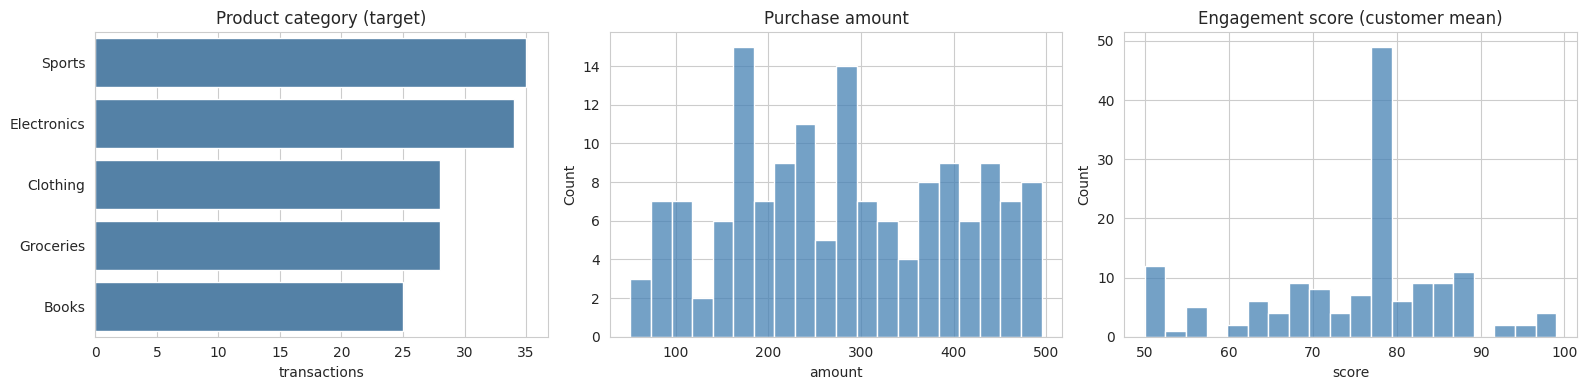

product_category
Sports         35
Electronics    34
Clothing       28
Groceries      28
Books          25
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

order = df['product_category'].value_counts().index
sns.countplot(data=df, y='product_category', order=order, ax=axes[0], color='steelblue')
axes[0].set_title('Product category (target)')
axes[0].set_xlabel('transactions')
axes[0].set_ylabel('')

sns.histplot(df['purchase_amount'], bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Purchase amount')
axes[1].set_xlabel('amount')

sns.histplot(df['engagement_score'], bins=20, ax=axes[2], color='steelblue')
axes[2].set_title('Engagement score (customer mean)')
axes[2].set_xlabel('score')

plt.tight_layout()
plt.show()

print(df['product_category'].value_counts())

The target is close to balanced across five categories, so accuracy is a fair metric here
and no class weighting is needed. The largest class is 23.3% of the data, which is the
baseline any model has to beat to be worth anything.

`purchase_amount` is broadly flat rather than bell shaped, and engagement score piles up
in the middle because unmatched customers were filled with the median.

## 5. Plot 2 - outliers

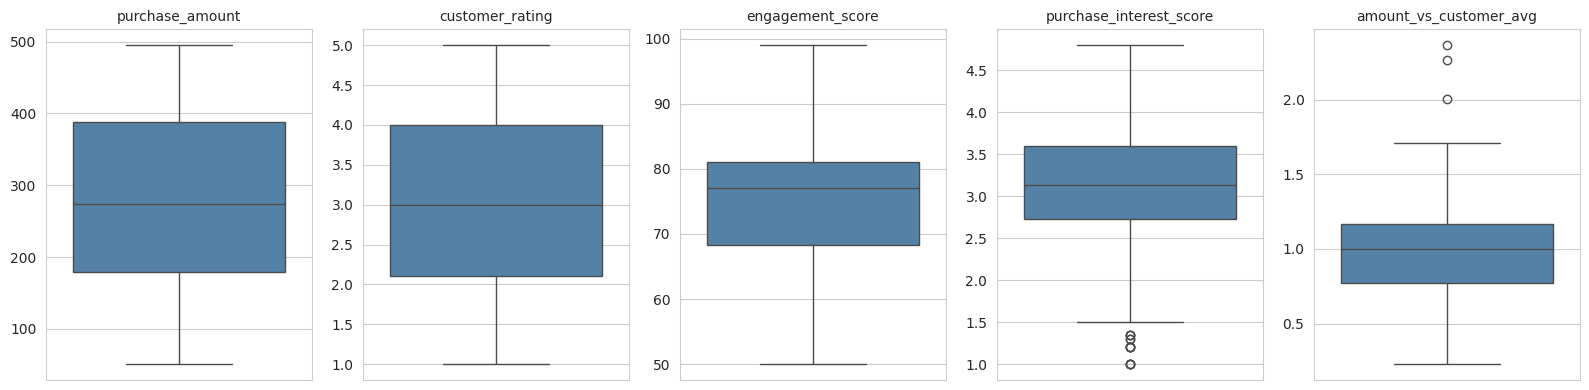

purchase_amount            0 outliers by 1.5*IQR
customer_rating            0 outliers by 1.5*IQR
engagement_score           0 outliers by 1.5*IQR
purchase_interest_score    13 outliers by 1.5*IQR
amount_vs_customer_avg     3 outliers by 1.5*IQR


In [9]:
num = ['purchase_amount', 'customer_rating', 'engagement_score',
       'purchase_interest_score', 'amount_vs_customer_avg']

fig, axes = plt.subplots(1, len(num), figsize=(16, 4))
for ax, col in zip(axes, num):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

for col in num:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f'{col:26s} {n} outliers by 1.5*IQR')

The only column with real outliers is `amount_vs_customer_avg`, and those are customers
with a single transaction or a very uneven spend, not data errors. Nothing here needs
clipping or removal.

## 6. Plot 3 - correlations

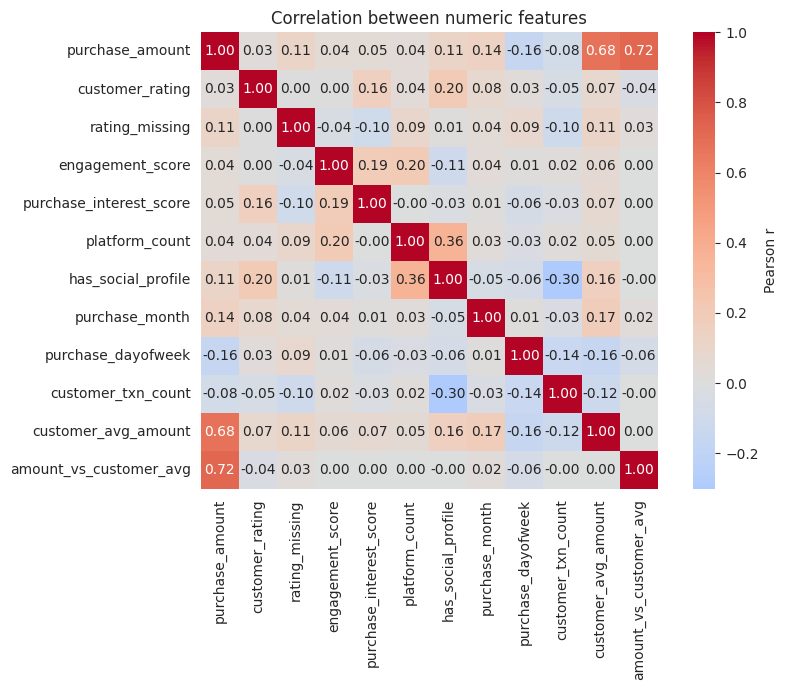

In [10]:
corr = df.select_dtypes('number').drop(columns=['transaction_id', 'customer_id']).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()

Nothing correlates with anything except where I built the relationship myself
(`purchase_amount` with `amount_vs_customer_avg`, and the engagement/interest pair coming
from the same aggregation). The social features and the transaction features are
essentially independent of each other.

## 7. Plot 4 - do any features actually separate the target?

The correlation heatmap only covers numeric pairs, and the target is categorical, so it
cannot show whether the features predict the product. Testing that directly.

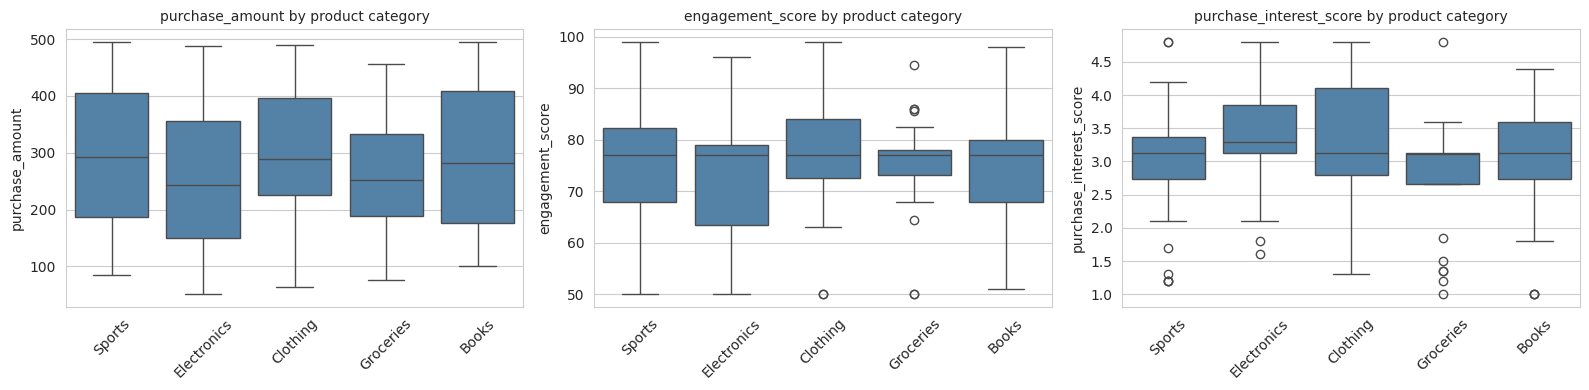

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['purchase_amount', 'engagement_score', 'purchase_interest_score']):
    sns.boxplot(data=df, x='product_category', y=col, ax=ax, color='steelblue')
    ax.set_title(f'{col} by product category', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [12]:
print('ANOVA - numeric feature vs product_category')
for col in ['purchase_amount', 'customer_rating', 'engagement_score',
            'purchase_interest_score', 'customer_avg_amount', 'amount_vs_customer_avg']:
    groups = [g[col].values for _, g in df.groupby('product_category')]
    f, p = f_oneway(*groups)
    print(f'  {col:26s} F={f:6.3f}  p={p:.3f}')

print()
print('chi-square - categorical feature vs product_category')
for col in ['social_media_platform', 'review_sentiment', 'has_social_profile']:
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df[col], df['product_category']))
    print(f'  {col:26s} chi2={chi2:6.3f}  p={p:.3f}')

ANOVA - numeric feature vs product_category
  purchase_amount            F= 1.224  p=0.303
  customer_rating            F= 0.638  p=0.636
  engagement_score           F= 0.702  p=0.592
  purchase_interest_score    F= 2.161  p=0.076
  customer_avg_amount        F= 0.861  p=0.489
  amount_vs_customer_avg     F= 0.458  p=0.766

chi-square - categorical feature vs product_category
  social_media_platform      chi2=18.604  p=0.548
  review_sentiment           chi2= 4.622  p=0.969
  has_social_profile         chi2= 0.889  p=0.926


## What the EDA says

Every feature comes back non-significant against the target. The boxplots line up at the
same level across all five categories, no numeric feature separates them (all p > 0.05),
and neither platform nor sentiment shifts the mix.

So `product_category` in this dataset is close to independent of everything available to
predict it. That is a property of the data, not of the merge or the feature engineering,
and no extra features would change it.

This sets the expectation for the model: the majority class is 23.3% and random guessing
over five categories is 20%, so a fairly evaluated model should land around there. Any
score much above that would mean the target had leaked into the features or that the
model was being scored on data it trained on. I would rather report a model that scores
near baseline for a reason I can explain than one that looks good and is wrong.